In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

In [2]:
# 1. Data Collection / Loading
df = pd.read_csv('Walmart.csv')

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [4]:
# 2. Data Preprocessing & Feature Engineering
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [5]:
# Drop columns not needed for training
X = df.drop(columns=['Weekly_Sales', 'Date'])
y = df['Weekly_Sales']

In [6]:
X.head()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
0,1,0,42.31,2.572,211.096358,8.106,2,2010
1,1,1,38.51,2.548,211.242170,8.106,2,2010
2,1,0,39.93,2.514,211.289143,8.106,2,2010
3,1,0,46.63,2.561,211.319643,8.106,2,2010
4,1,0,46.50,2.625,211.350143,8.106,3,2010


In [7]:
y.head()

0    1643690.90
1    1641957.44
2    1611968.17
3    1409727.59
4    1554806.68
Name: Weekly_Sales, dtype: float64

In [8]:

# 3. Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
X_train.head()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
1033,8,0,75.32,2.582,214.878556,6.315,9,2010
915,7,0,20.70,3.372,192.058484,8.818,3,2011
5903,42,0,61.24,3.130,126.546161,9.003,11,2010
2083,15,0,69.19,3.906,136.213613,7.806,8,2011
5943,42,0,87.40,3.743,129.240581,8.257,8,2011


In [10]:
y_train.head()

1033    836707.85
915     558963.83
5903    588592.61
2083    605413.17
5943    526641.23
Name: Weekly_Sales, dtype: float64

In [11]:

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
X_train_scaled

array([[-1.16466588, -0.26842748,  0.8057783 , ..., -0.8978744 ,
         0.7955697 , -1.22576021],
       [-1.24165623, -0.26842748, -2.15108453, ...,  0.43847483,
        -1.05624317,  0.0325077 ],
       [ 1.45300579, -0.26842748,  0.04355515, ...,  0.53724615,
         1.41284065, -1.22576021],
       ...,
       [ 1.06805407, -0.26842748,  1.42237786, ...,  0.09624556,
         0.48693422,  0.0325077 ],
       [ 1.14504441,  3.72540101, -0.85508863, ...,  2.61251161,
         1.72147613,  0.0325077 ],
       [-1.24165623, -0.26842748, -1.79487513, ...,  0.54311904,
        -1.36487865, -1.22576021]])

In [14]:
X_test_scaled

array([[-0.39476245, -0.26842748, -0.97689275, ...,  0.64349205,
        -1.05624317, -1.22576021],
       [ 0.06717961, -0.26842748,  0.45714783, ...,  0.11493203,
        -0.13033674,  0.0325077 ],
       [-1.62660794, -0.26842748,  0.29420097, ..., -0.29670411,
         1.10420518,  0.0325077 ],
       ...,
       [ 1.68397682, -0.26842748, -1.79325108, ...,  0.53137326,
        -1.36487865, -1.22576021],
       [-1.62660794, -0.26842748,  0.15344954, ...,  0.10852524,
        -0.7476077 , -1.22576021],
       [-0.4717528 , -0.26842748, -1.9610701 , ..., -0.60369604,
        -1.05624317,  0.0325077 ]])

In [15]:
# 5. Model Training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)


RandomForestRegressor(random_state=42)

In [16]:
# 6. Model Evaluation
y_pred = model.fit(X_train_scaled, y_train).predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [17]:
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error: 72362.47
R2 Score: 0.9399


In [18]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
# Initialize Excel writer
with pd.ExcelWriter('Walmart_Analysis_Dashboard.xlsx', engine='openpyxl') as writer:
    
    # Sheet 1: EDA Summary
    eda_desc = df.describe().reset_index()
    missing_vals = pd.DataFrame(df.isnull().sum()).reset_index().rename(columns={'index': 'Column', 0: 'Missing_Values'})
    eda_summary = pd.concat([eda_desc, missing_vals], axis=1)
    eda_summary.to_excel(writer, sheet_name='EDA Summary', index=False)
    
    # Model Setup for Predictions
    df['Month'] = df['Date'].dt.month
    df['Year'] = df['Date'].dt.year
    X = df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year']]
    y = df['Weekly_Sales']
    
    # Train simple model (Random Forest)
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(n_estimators=50, random_state=42)
    model.fit(X, y)
    preds = model.predict(X)
    
    # Sheet 2: Predictions and Actuals
    pred_actuals_df = pd.DataFrame({
        'Date': df['Date'].dt.strftime('%Y-%m-%d'),
        'Actual_Sales': y,
        'Predicted_Sales': preds,
        'Absolute_Error': np.abs(y - preds),
        'Variance_Percentage': ((preds - y) / y) * 100
    })
    pred_actuals_df.to_excel(writer, sheet_name='Predictions & Actuals', index=False)
    
    # Sheet 3: Plots Data
    # Aggregating time series metrics so a line chart can be easily plotted
    plots_data = pred_actuals_df.groupby('Date')[['Actual_Sales', 'Predicted_Sales']].mean().reset_index()
    plots_data.to_excel(writer, sheet_name='Plots Data', index=False)
    
    # Sheet 4: Output Results
    # Consolidating summary KPIs across sheets
    mae = np.mean(pred_actuals_df['Absolute_Error'])
    mape = np.mean(np.abs(pred_actuals_df['Variance_Percentage']))
    r2 = model.score(X, y)
    
    output_results = pd.DataFrame({
        'Metric': ['Total Rows Evaluated', 'Mean Absolute Error (MAE)', 'Mean Absolute Percentage Error (MAPE)', 'Model R2 Score'],
        'Value': [len(df), mae, f"{mape:.2f}%", f"{r2:.4f}"]
    })
    output_results.to_excel(writer, sheet_name='Output Results', index=False)

print("Workbook with all 4 sheets derived successfully!")

Workbook with all 4 sheets derived successfully!


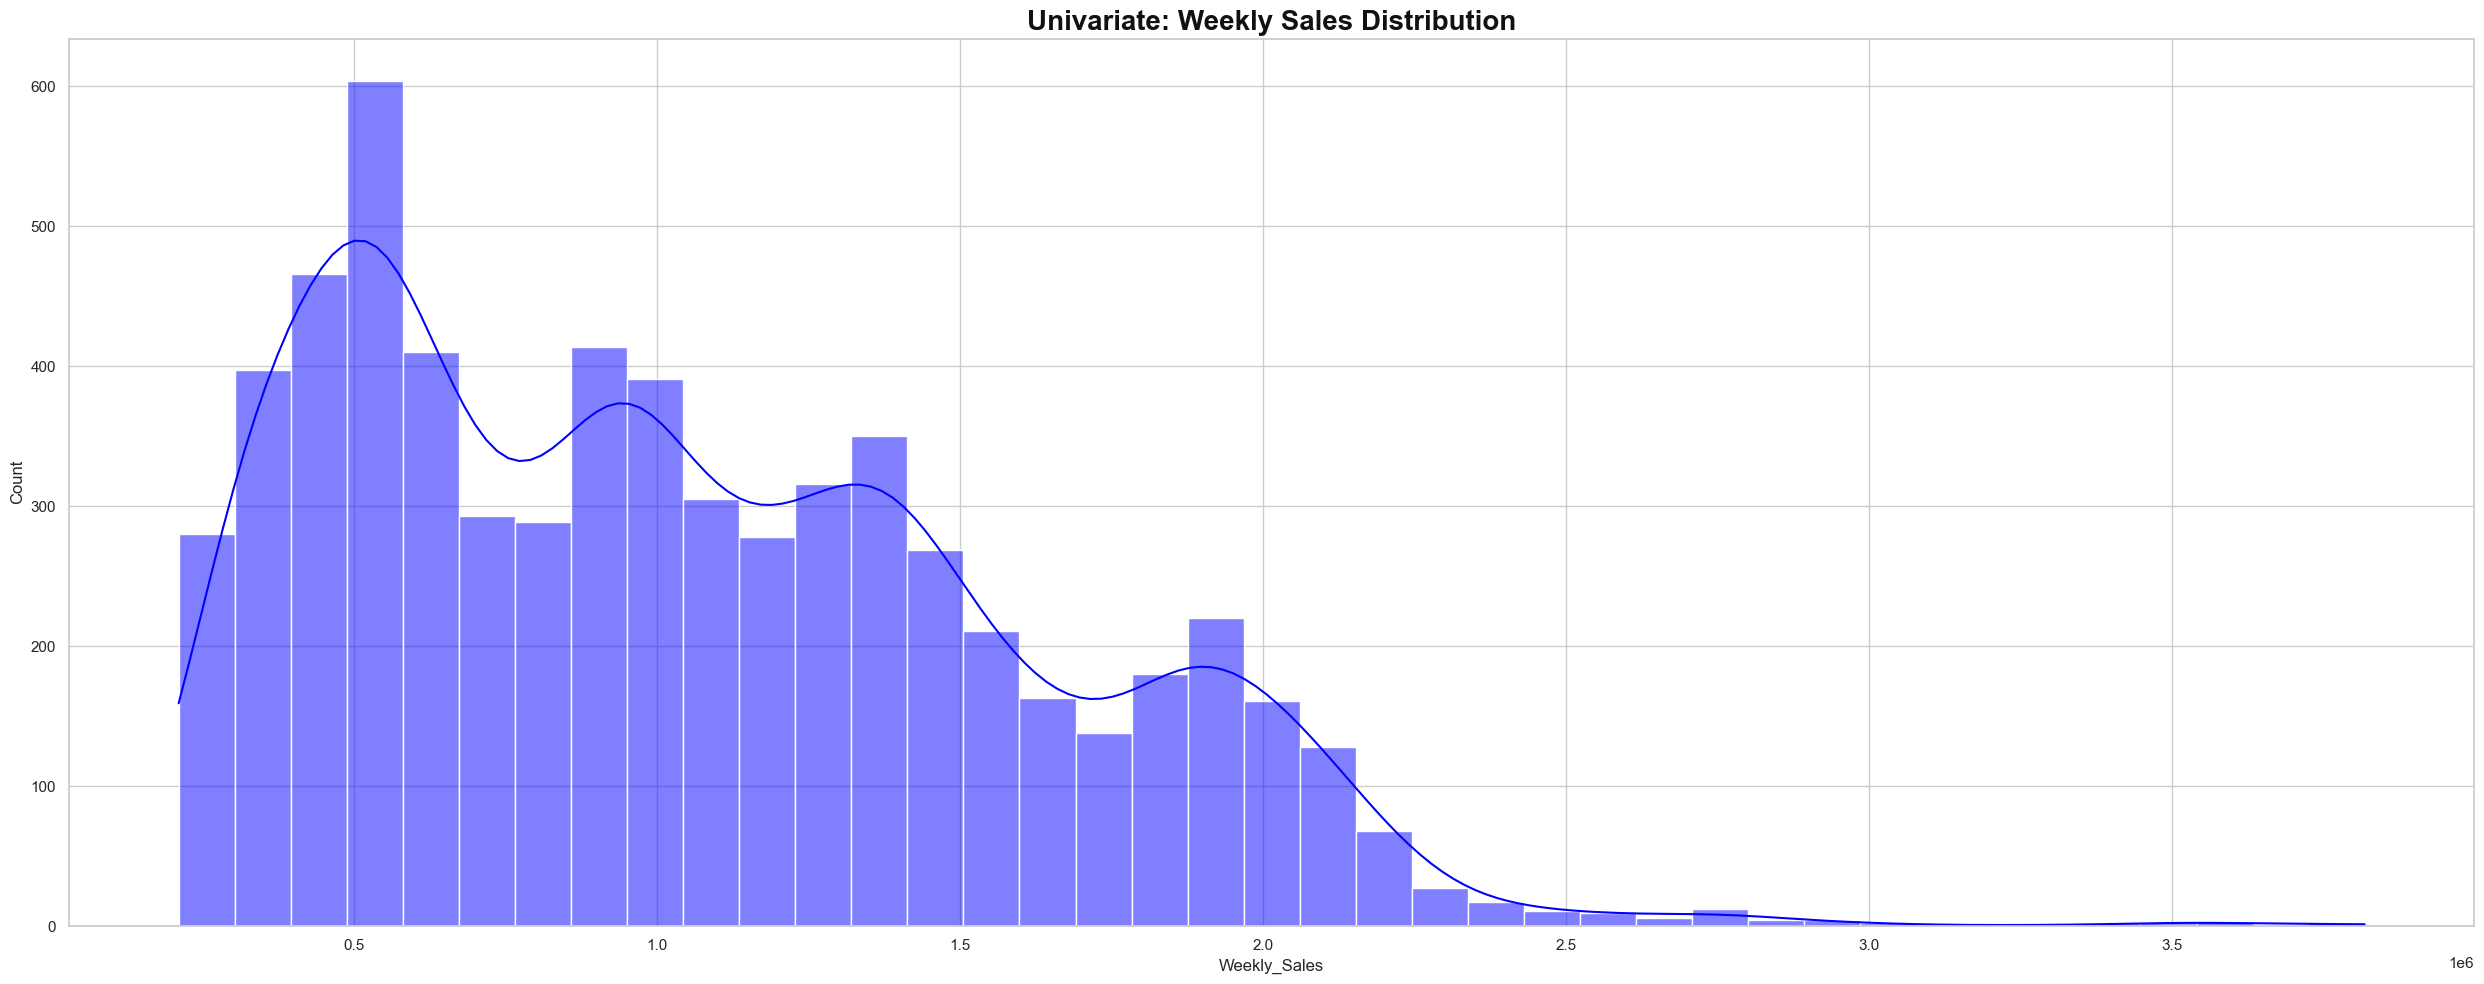

In [24]:
# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(figsize=(25, 10))

# 1. Univariate Analysis (Single variable distribution)
# Visualizes the frequency and spread of Weekly_Sales
sns.histplot(df['Weekly_Sales'], kde=True, ax=axes, color='blue')
axes.set_title('Univariate: Weekly Sales Distribution', fontsize=20, color='#111111', fontweight='bold')
plt.tight_layout()
plt.show()

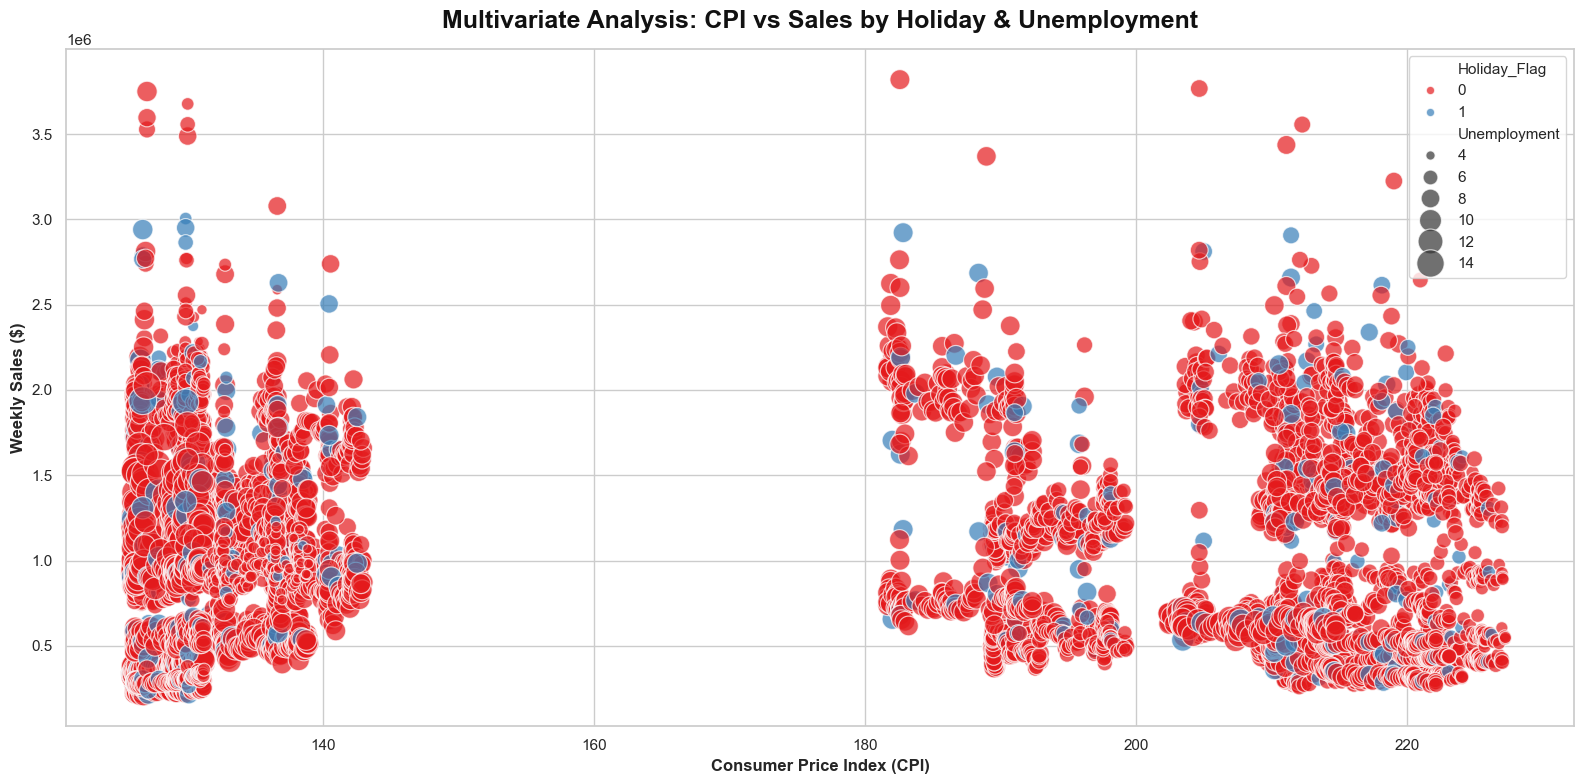

In [26]:
# 1. Set background style aesthetics
sns.set_theme(style='whitegrid') 

# 2. Initialize figure and single axes subplot
fig, ax = plt.subplots(figsize=(16, 8)) 

# 3. Multivariate Plot: CPI vs Weekly Sales mapped by Holiday (Hue) and Unemployment (Size)
sns.scatterplot(
    data=df, 
    x='CPI', 
    y='Weekly_Sales', 
    hue='Holiday_Flag', 
    size='Unemployment',
    sizes=(40, 400), 
    alpha=0.7,
    palette='Set1', 
    ax=ax
)

# 4. Refine title and clean presentation layout
ax.set_title('Multivariate Analysis: CPI vs Sales by Holiday & Unemployment', fontsize=18, color='#111111', fontweight='bold', pad=15)
ax.set_xlabel('Consumer Price Index (CPI)', fontsize=12, fontweight='bold')
ax.set_ylabel('Weekly Sales ($)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

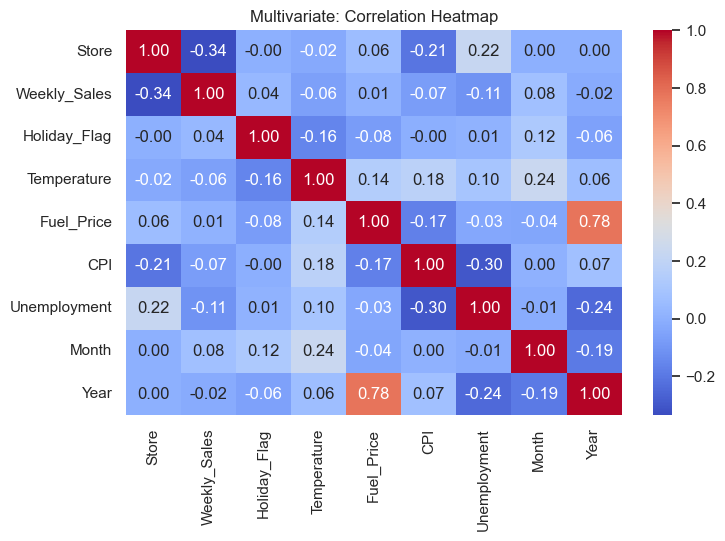

In [27]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.drop(columns=['Date']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Multivariate: Correlation Heatmap')
plt.show()

In [28]:

# 7. Deployment Preparation (Save Artifacts)
joblib.dump(model, 'walmart_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']